In [1]:
import qsample as qs
import time
import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching

/Users/jhfontes/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


p=('1.00e-02',): 100%|██████████| 1000/1000 [00:00<00:00, 4476.74it/s]


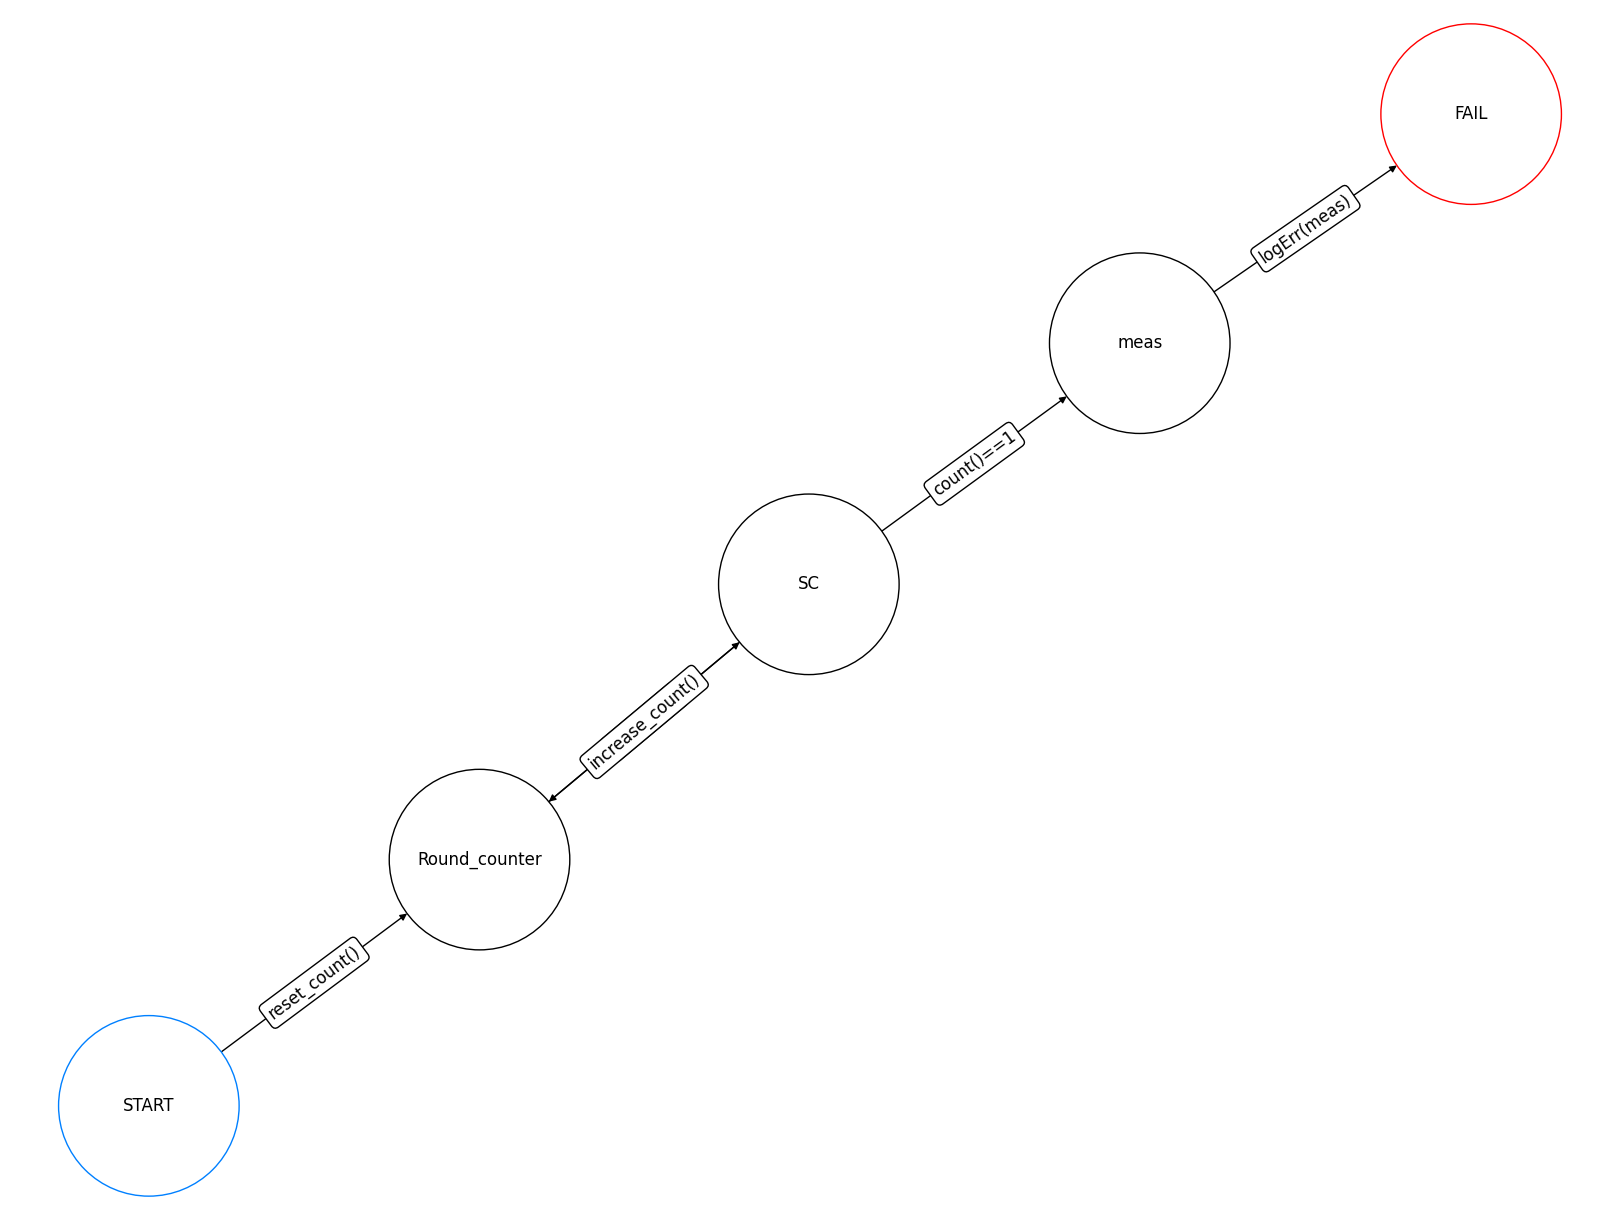

In [2]:
distance = 3
meas_array = np.arange(distance)*(2*distance+1)+1
meas_str=""
for m in meas_array:
    meas_str+=" "
    meas_str+=str(m)

circuit = stim.Circuit.generated("surface_code:rotated_memory_x", rounds=1, distance=distance, after_clifford_depolarization=0.05,
    after_reset_flip_probability=0.001,
    before_measure_flip_probability=0.001,
    before_round_data_depolarization=0.001,)
surface_code = qs.Circuit(noisy=True).from_stim_circuit(circuit)

meas = qs.Circuit(noisy=False).from_stim_circuit("""M"""+meas_str)

round_ = 0
def reset_count():
    global round_
    round_=0
    return True

def increase_count():
    global round_
    round_+=1
    return round_

def count():
    global round_
    return round_



def logErr(out):
    meas_1 = 0
    for i in range(distance):
        j = (out[0]>=(2**(distance-1-i)))
        meas_1+=j
        out[0]-=2**(distance-1-i)*j
    return meas_1%2

functions = {'logErr':logErr,
            'reset_count': reset_count, 'count': count, 'increase_count': increase_count}
surface = qs.Protocol(check_functions=functions)


n_rounds = 1
surface.add_nodes_from(['SC', 'meas'], circuits=[surface_code, meas])
surface.add_node('Round_counter', circuit=qs.Circuit([{"I": {0}}],noisy=False))
surface.add_edge('START', 'Round_counter', check='reset_count()')
surface.add_edge('Round_counter', 'SC', check='increase_count()')
surface.add_edge('SC', 'Round_counter', check=f'count()<{n_rounds}')
surface.add_edge('SC', 'meas', check=f'count()=={n_rounds}')
surface.add_edge('meas', 'FAIL', check='logErr(meas)')

surface.draw(figsize=(16,12), path='protocol_surface')

err_model = qs.noise.E1
stim_sam = qs.SplittingSampler(1000, protocol=surface, simulator=qs.StimSimulator,  p_max={'q': [0.01]}, err_model=err_model, distance=distance)
#stim_sam = qs.SplittingSampler(protocol=steane0, simulator=qs.StimSimulator,  err_model=err_model, err_params=err_params)
#stim_sam.run(1e-4)


In [6]:
begin_time = time.time()
stim_sam.calculate_error(0.00001, 1000)
end_time = time.time()
print(end_time-begin_time)

100%|██████████| 13/13 [00:41<00:00,  3.16s/it]

41.83584713935852


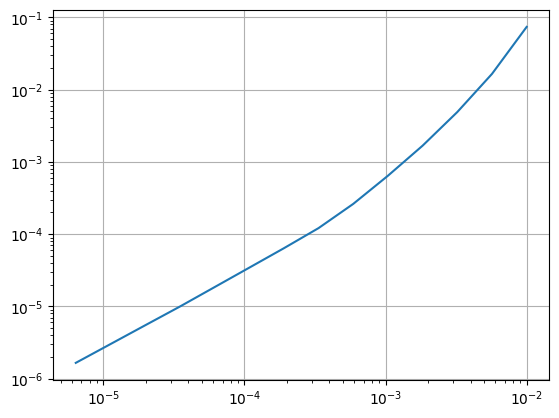

In [7]:
plt.plot(stim_sam.physical_p, stim_sam.logical_p)
plt.xscale('log')
plt.yscale('log')
plt.grid()

p=('1.00e-02',): 100%|██████████| 2000/2000 [00:00<00:00, 3599.40it/s]


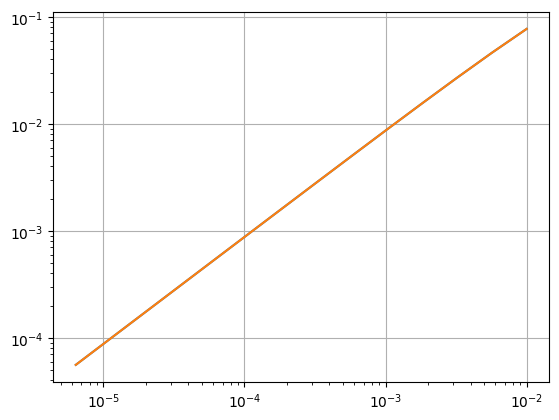

In [8]:
err_params = {'q': stim_sam.physical_p}

subset_sam = qs.SubsetSampler(protocol=surface, simulator=qs.StimSimulator,  p_max={'q': 0.01}, err_model=err_model, err_params=err_params, L=3)
subset_sam.run(2000)

v = subset_sam.stats()[0]
w = subset_sam.stats()[2]

plt.plot(stim_sam.physical_p, v)
plt.plot(stim_sam.physical_p, w)
plt.xscale('log')
plt.yscale('log')
plt.grid()
